In [9]:
import pandas as pd

In [10]:
df = pd.read_parquet("yellow_tripdata_2026-01.parquet")

In [11]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


## Preparação dos dados

Cálculo de campos derivados (duração da viagem, hora do dia) e remoção de registros inválidos (distância, duração ou valor <= 0).

In [12]:
import matplotlib.pyplot as plt

df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

df["trip_duration_min"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour

# Remove corridas com valores inválidos (distância, duração ou valor <= 0)
df_valid = df[
    (df["trip_distance"] > 0)
    & (df["trip_duration_min"] > 0)
    & (df["total_amount"] > 0)
].copy()

print(f"Registros originais: {len(df):,}")
print(f"Registros válidos:   {len(df_valid):,}")

Matplotlib is building the font cache; this may take a moment.


Registros originais: 3,724,889
Registros válidos:   3,517,909


## Estatísticas gerais

Quantidade de corridas, distância média, duração média e valor médio.

In [13]:
stats = {
    "quantidade_corridas": len(df_valid),
    "distancia_media_milhas": df_valid["trip_distance"].mean(),
    "duracao_media_min": df_valid["trip_duration_min"].mean(),
    "valor_medio_usd": df_valid["total_amount"].mean(),
    "passageiros_medio": df_valid["passenger_count"].mean(),
}

for nome, valor in stats.items():
    print(f"{nome:25s}: {valor:,.2f}")

quantidade_corridas      : 3,517,909.00
distancia_media_milhas   : 6.76
duracao_media_min        : 17.47
valor_medio_usd          : 29.68
passageiros_medio        : 1.25


## Distribuição de corridas por horário do dia

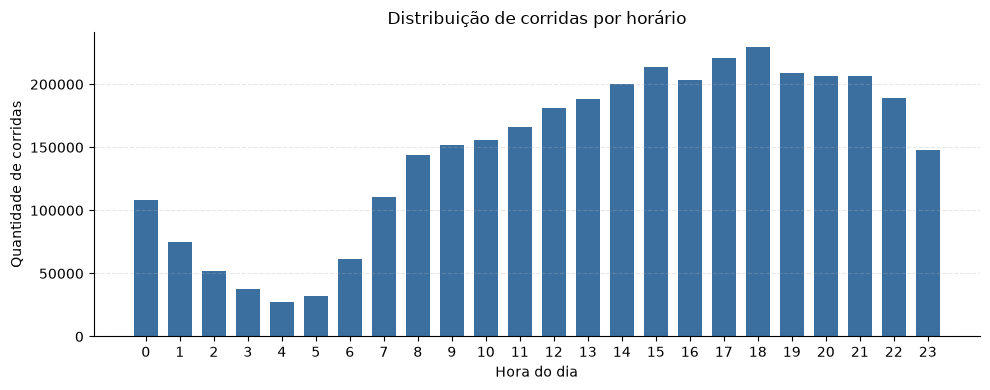

In [14]:
corridas_por_hora = df_valid["pickup_hour"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(corridas_por_hora.index, corridas_por_hora.values, color="#3B6FA0", width=0.7)
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Quantidade de corridas")
ax.set_title("Distribuição de corridas por horário")
ax.set_xticks(range(0, 24))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Distribuição de corridas por região (top 15 zonas de embarque)

`PULocationID` é o identificador da zona de embarque (Pickup Location). O mapeamento oficial de ID → nome de zona/bairro está no arquivo `taxi_zone_lookup.csv` da NYC TLC, caso queira nomes em vez de IDs.

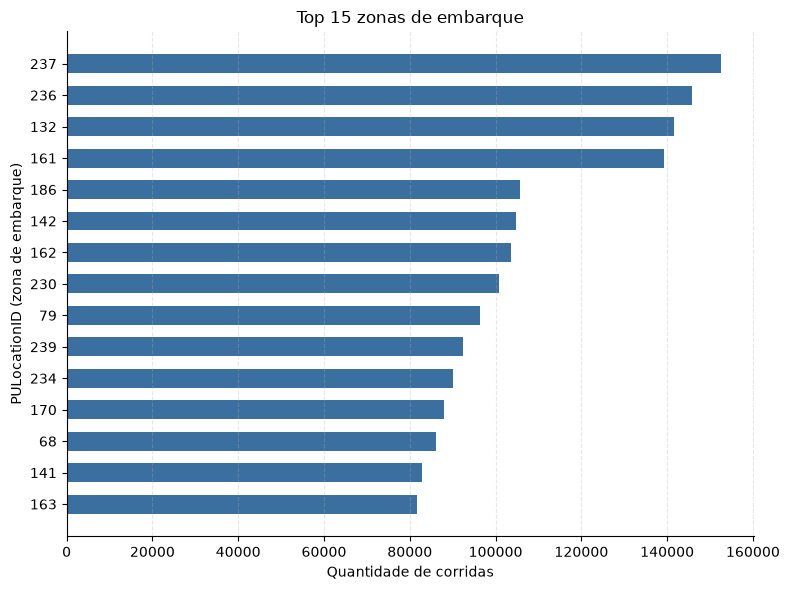

In [15]:
top_regioes = df_valid["PULocationID"].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_regioes.index.astype(str), top_regioes.values, color="#3B6FA0", height=0.6)
ax.set_xlabel("Quantidade de corridas")
ax.set_ylabel("PULocationID (zona de embarque)")
ax.set_title("Top 15 zonas de embarque")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Função consolidada

Reúne os passos acima em uma função reaproveitável para analisar outros arquivos/meses.

In [16]:
def analisar_corridas(df_raw: pd.DataFrame) -> dict:
    """Calcula estatísticas de corridas de táxi a partir de um DataFrame bruto.

    Retorna um dicionário com estatísticas gerais e as distribuições
    por horário e por região de embarque.
    """
    df = df_raw.copy()
    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
    df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])
    df["trip_duration_min"] = (
        df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60
    df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour

    df_valid = df[
        (df["trip_distance"] > 0)
        & (df["trip_duration_min"] > 0)
        & (df["total_amount"] > 0)
    ]

    return {
        "quantidade_corridas": len(df_valid),
        "distancia_media_milhas": df_valid["trip_distance"].mean(),
        "duracao_media_min": df_valid["trip_duration_min"].mean(),
        "valor_medio_usd": df_valid["total_amount"].mean(),
        "passageiros_medio": df_valid["passenger_count"].mean(),
        "corridas_por_hora": df_valid["pickup_hour"].value_counts().sort_index(),
        "corridas_por_regiao": df_valid["PULocationID"].value_counts(),
    }


resultado = analisar_corridas(df)
{k: v for k, v in resultado.items() if not isinstance(v, pd.Series)}

{'quantidade_corridas': 3517909,
 'distancia_media_milhas': np.float64(6.757239991142466),
 'duracao_media_min': np.float64(17.473333652651807),
 'valor_medio_usd': np.float64(29.675138745771992),
 'passageiros_medio': np.float64(1.2539836258775037)}